In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df=pd.read_csv("retail sales.csv",encoding="unicode_escape",delimiter=";")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,1.12.2009 07:45,"6,95",13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12.0,1.12.2009 07:45,"6,75",13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,1.12.2009 07:45,"6,75",13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,1.12.2009 07:45,"2,1",13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,1.12.2009 07:45,"1,25",13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
49346,493989,21536,DAIRY MAID SMALL MILK JUG,2.0,10.01.2010 12:43,"2,1",14685.0,United Kingdom
49347,493989,21540,DAIRY MAID CERAMIC BUTTER DISH,1.0,10.01.2010 12:43,"4,25",14685.0,United Kingdom
49348,493989,22064,PINK DOUGHNUT TRINKET POT,6.0,10.01.2010 12:43,"1,65",14685.0,United Kingdom
49349,493989,21536,DAIRY MAID SMALL MILK JUG,4.0,10.01.2010 12:43,"2,1",14685.0,United Kingdom


In [7]:
df.isna().sum()

,0
Invoice,0
StockCode,1
Description,267
Quantity,1
InvoiceDate,1
Price,1
Customer ID,13543
Country,1


In [8]:
df.dropna(inplace=True)

In [9]:
df.isna().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [17]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,float64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


In [16]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%d.%m.%Y %H:%M")
df['Price'] = df['Price'].astype(str).str.replace(',', '.').astype(float)

In [18]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [23]:
df_recency=df.groupby(by="Customer ID",as_index=False)["InvoiceDate"].max()

In [24]:
df_recency

,Customer ID,InvoiceDate
0,12346.0,2010-01-04 09:53:00
1,12349.0,2009-12-04 12:49:00
2,12358.0,2009-12-08 07:59:00
3,12359.0,2009-12-16 15:39:00
4,12362.0,2009-12-01 10:10:00
...,...,...
1102,18271.0,2009-12-08 11:27:00
1103,18275.0,2009-12-08 16:23:00
1104,18276.0,2009-12-10 17:14:00
1105,18286.0,2009-12-16 10:45:00


In [26]:
recent_date=df_recency["InvoiceDate"].max()

In [27]:
recent_date

Timestamp('2010-01-10 12:43:00')

In [35]:
df_recency=df.groupby(by="Customer ID",as_index=False)["InvoiceDate"].max()
recent_date=df_recency["InvoiceDate"].max()
df_recency["Recency"] = (recent_date - df_recency['InvoiceDate']).dt.days

In [36]:
df_recency

,Customer ID,InvoiceDate,Recency
0,12346.0,2010-01-04 09:53:00,6
1,12349.0,2009-12-04 12:49:00,36
2,12358.0,2009-12-08 07:59:00,33
3,12359.0,2009-12-16 15:39:00,24
4,12362.0,2009-12-01 10:10:00,40
...,...,...,...
1102,18271.0,2009-12-08 11:27:00,33
1103,18275.0,2009-12-08 16:23:00,32
1104,18276.0,2009-12-10 17:14:00,30
1105,18286.0,2009-12-16 10:45:00,25


In [38]:
df_freq=df.drop_duplicates().groupby(by="Customer ID",as_index=False)["InvoiceDate"].count()
df_freq.columns=["Customer ID","Frequency"]

In [39]:
df_freq

,Customer ID,Frequency
0,12346.0,7
1,12349.0,5
2,12358.0,17
3,12359.0,36
4,12362.0,1
...,...,...
1102,18271.0,9
1103,18275.0,9
1104,18276.0,16
1105,18286.0,17


In [41]:
df["total_price"]=df['Price']*df['Quantity']
df['total_price']

,total_price
0,83.40
1,81.00
2,81.00
3,100.80
4,30.00
...,...
49345,12.75
49346,4.20
49347,4.25
49348,9.90


In [42]:
df_monitary=df.groupby(by="Customer ID",as_index=False)["total_price"].sum()
df_monitary

,Customer ID,total_price
0,12346.0,158.50
1,12349.0,-24.15
2,12358.0,1429.83
3,12359.0,760.69
4,12362.0,130.00
...,...,...
1102,18271.0,192.55
1103,18275.0,372.64
1104,18276.0,218.05
1105,18286.0,462.95


In [43]:
RFM=df_recency.merge(df_freq,on="Customer ID").merge(df_monitary,on="Customer ID")

In [45]:
RFM.columns=["Customer ID","Last_date","Recency","Frequency","Monitary"]

In [49]:
RFM["R_Rank"]=RFM['Recency'].rank(ascending=False)
RFM["F_Rank"]=RFM["Frequency"].rank(ascending=False)
RFM["M_Rank"]=RFM['Monitary'].rank(ascending=False)

In [50]:
RFM

,Customer ID,Last_date,Recency,Frequency,Monitary,Rank,R_Rank,F_Rank,M_Rank
0,12346.0,2010-01-04 09:53:00,6,7,158.50,924.5,924.5,867.0,847.0
1,12349.0,2009-12-04 12:49:00,36,5,-24.15,200.0,200.0,922.0,1069.0
2,12358.0,2009-12-08 07:59:00,33,17,1429.83,296.5,296.5,613.0,98.0
3,12359.0,2009-12-16 15:39:00,24,36,760.69,721.5,721.5,305.0,219.0
4,12362.0,2009-12-01 10:10:00,40,1,130.00,13.5,13.5,1073.5,901.0
...,...,...,...,...,...,...,...,...,...
1102,18271.0,2009-12-08 11:27:00,33,9,192.55,296.5,296.5,806.5,780.0
1103,18275.0,2009-12-08 16:23:00,32,9,372.64,350.5,350.5,806.5,478.0
1104,18276.0,2009-12-10 17:14:00,30,16,218.05,463.5,463.5,632.5,732.0
1105,18286.0,2009-12-16 10:45:00,25,17,462.95,661.5,661.5,613.0,390.0


In [52]:
RFM["R_rank_norm"]=(RFM["R_Rank"]/RFM["R_Rank"].max())*100
RFM["F_rank_norm"]=(RFM["F_Rank"]/RFM["F_Rank"].max())*100
RFM["M_rank_norm"]=(RFM["M_Rank"]/RFM["M_Rank"].max())*100

In [53]:
RFM

,Customer ID,Last_date,Recency,Frequency,Monitary,Rank,R_Rank,F_Rank,M_Rank,R_rank_norm,F_rank_norm,M_rank_norm
0,12346.0,2010-01-04 09:53:00,6,7,158.50,924.5,924.5,867.0,847.0,84.121929,80.763857,76.513098
1,12349.0,2009-12-04 12:49:00,36,5,-24.15,200.0,200.0,922.0,1069.0,18.198362,85.887285,96.567299
2,12358.0,2009-12-08 07:59:00,33,17,1429.83,296.5,296.5,613.0,98.0,26.979072,57.102934,8.852755
3,12359.0,2009-12-16 15:39:00,24,36,760.69,721.5,721.5,305.0,219.0,65.650591,28.411737,19.783198
4,12362.0,2009-12-01 10:10:00,40,1,130.00,13.5,13.5,1073.5,901.0,1.228389,100.000000,81.391147
...,...,...,...,...,...,...,...,...,...,...,...,...
1102,18271.0,2009-12-08 11:27:00,33,9,192.55,296.5,296.5,806.5,780.0,26.979072,75.128086,70.460705
1103,18275.0,2009-12-08 16:23:00,32,9,372.64,350.5,350.5,806.5,478.0,31.892630,75.128086,43.179765
1104,18276.0,2009-12-10 17:14:00,30,16,218.05,463.5,463.5,632.5,732.0,42.174704,58.919422,66.124661
1105,18286.0,2009-12-16 10:45:00,25,17,462.95,661.5,661.5,613.0,390.0,60.191083,57.102934,35.230352


In [54]:
RFM['RFM_score']=0.15*RFM["R_rank_norm"]+0.28*RFM['F_rank_norm']+0.57*RFM['M_rank_norm']
RFM['RFM_score']*=0.05
RFM=RFM.round(2)
RFM

,Customer ID,Last_date,Recency,Frequency,Monitary,Rank,R_Rank,F_Rank,M_Rank,R_rank_norm,F_rank_norm,M_rank_norm,RFM_score
0,12346.0,2010-01-04 09:53:00,6,7,158.50,924.5,924.5,867.0,847.0,84.12,80.76,76.51,3.94
1,12349.0,2009-12-04 12:49:00,36,5,-24.15,200.0,200.0,922.0,1069.0,18.20,85.89,96.57,4.09
2,12358.0,2009-12-08 07:59:00,33,17,1429.83,296.5,296.5,613.0,98.0,26.98,57.10,8.85,1.25
3,12359.0,2009-12-16 15:39:00,24,36,760.69,721.5,721.5,305.0,219.0,65.65,28.41,19.78,1.45
4,12362.0,2009-12-01 10:10:00,40,1,130.00,13.5,13.5,1073.5,901.0,1.23,100.00,81.39,3.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,18271.0,2009-12-08 11:27:00,33,9,192.55,296.5,296.5,806.5,780.0,26.98,75.13,70.46,3.26
1103,18275.0,2009-12-08 16:23:00,32,9,372.64,350.5,350.5,806.5,478.0,31.89,75.13,43.18,2.52
1104,18276.0,2009-12-10 17:14:00,30,16,218.05,463.5,463.5,632.5,732.0,42.17,58.92,66.12,3.03
1105,18286.0,2009-12-16 10:45:00,25,17,462.95,661.5,661.5,613.0,390.0,60.19,57.10,35.23,2.25


In [57]:
RFM["Costumers_seg"]=np.where(RFM['RFM_score']>4.5,"TOP_costumer",
                              (np.where(RFM['RFM_score']>4,"High_value_costumer",
                                        (np.where(RFM['RFM_score']>3,"Mid_value_costumer",
                                                  (np.where(RFM['RFM_score']>1.6,"Low_value_costumer","Lost_custumer")))))))

In [58]:
RFM

,Customer ID,Last_date,Recency,Frequency,Monitary,Rank,R_Rank,F_Rank,M_Rank,R_rank_norm,F_rank_norm,M_rank_norm,RFM_score,Costumers_seg
0,12346.0,2010-01-04 09:53:00,6,7,158.50,924.5,924.5,867.0,847.0,84.12,80.76,76.51,3.94,Mid_value_costumer
1,12349.0,2009-12-04 12:49:00,36,5,-24.15,200.0,200.0,922.0,1069.0,18.20,85.89,96.57,4.09,High_value_costumer
2,12358.0,2009-12-08 07:59:00,33,17,1429.83,296.5,296.5,613.0,98.0,26.98,57.10,8.85,1.25,Lost_custumer
3,12359.0,2009-12-16 15:39:00,24,36,760.69,721.5,721.5,305.0,219.0,65.65,28.41,19.78,1.45,Lost_custumer
4,12362.0,2009-12-01 10:10:00,40,1,130.00,13.5,13.5,1073.5,901.0,1.23,100.00,81.39,3.73,Mid_value_costumer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,18271.0,2009-12-08 11:27:00,33,9,192.55,296.5,296.5,806.5,780.0,26.98,75.13,70.46,3.26,Mid_value_costumer
1103,18275.0,2009-12-08 16:23:00,32,9,372.64,350.5,350.5,806.5,478.0,31.89,75.13,43.18,2.52,Low_value_costumer
1104,18276.0,2009-12-10 17:14:00,30,16,218.05,463.5,463.5,632.5,732.0,42.17,58.92,66.12,3.03,Mid_value_costumer
1105,18286.0,2009-12-16 10:45:00,25,17,462.95,661.5,661.5,613.0,390.0,60.19,57.10,35.23,2.25,Low_value_costumer


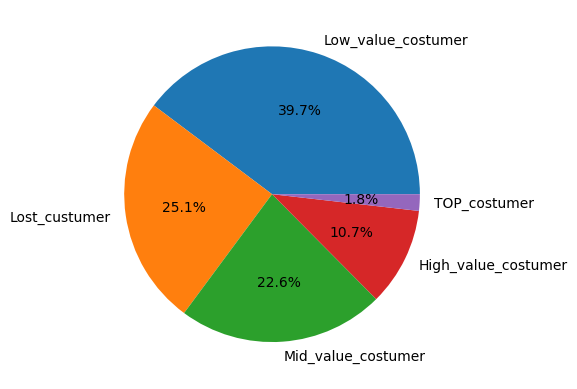

In [61]:
plt.pie(RFM['Costumers_seg'].value_counts(),labels=RFM['Costumers_seg'].value_counts().index,autopct='%1.1f%%')
plt.show()